# K-IFRS Agentic RAG Chain

Hybrid Retriever → Reranker → **LLM ↔ Tool 루프** (상호참조 자동 검색)

- **Retriever**: QdrantDenseRetriever + BM25Retriever → EnsembleRetriever (Top-30)
- **Reranker**: LocalReranker 또는 CohereReranker (Top-10)
- **LLM**: Claude (bind_tools로 fetch_paragraphs tool 제공)
- **Graph**: retrieve → rerank → generate ⇄ tool_executor → END

In [1]:
import os
import json
import glob
import time
import pickle
import hashlib
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_upstage import UpstageEmbeddings
from langchain_anthropic import ChatAnthropic
from qdrant_client import QdrantClient
from qdrant_client.models import Filter, FieldCondition, MatchValue
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

from search.config import QDRANT_PATH, CHUNKS_DIR, CHILD_COLLECTION, PARENT_COLLECTION, MODEL_NAME
from search.retriever import QdrantDenseRetriever, load_child_documents, kiwi_tokenize
from search.reranker import get_reranker

load_dotenv()
print("패키지 로드 완료")

c:\Study\_database\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


패키지 로드 완료


## 1. 설정

In [2]:
RETRIEVAL_K = 30    # Hybrid 검색 후보 수
RERANK_TOP_N = 5    # Reranker 후 LLM 전달 수
TOP_K = RERANK_TOP_N  # backward compat

## 2. Hybrid Retriever 구성

In [3]:
# BM25 캐시 관리
BM25_CACHE_DIR = Path(".")
BM25_PKL_PATH = BM25_CACHE_DIR / "bm25_retriever.pkl"
BM25_META_PATH = BM25_CACHE_DIR / "bm25_cache_meta.json"


def _docs_fingerprint(docs: list[Document]) -> str:
    """문서 수 + 첫/마지막 문서 내용으로 MD5 fingerprint 생성"""
    h = hashlib.md5()
    h.update(str(len(docs)).encode())
    if docs:
        h.update(docs[0].page_content.encode())
        h.update(docs[-1].page_content.encode())
    return h.hexdigest()


def load_or_build_bm25(
    docs: list[Document], preprocess_func, k: int
) -> BM25Retriever:
    fingerprint = _docs_fingerprint(docs)

    # 캐시 유효성 검사
    if BM25_PKL_PATH.exists() and BM25_META_PATH.exists():
        meta = json.loads(BM25_META_PATH.read_text(encoding="utf-8"))
        if meta.get("fingerprint") == fingerprint:
            print(f"  캐시 적중 — {BM25_PKL_PATH} 로드 중...")
            t0 = time.time()
            with open(BM25_PKL_PATH, "rb") as f:
                retriever = pickle.load(f)
            retriever.k = k
            print(f"  BM25 캐시 로드 완료 ({time.time() - t0:.1f}초)")
            return retriever
        else:
            print("  캐시 fingerprint 불일치 — 재빌드합니다.")

    # 캐시 미스: 새로 빌드
    print(f"  BM25 인덱스 빌드 중... (문서 {len(docs)}개)")
    t0 = time.time()
    retriever = BM25Retriever.from_documents(
        docs, preprocess_func=preprocess_func, k=k
    )
    elapsed = time.time() - t0
    print(f"  BM25 인덱스 빌드 완료 ({elapsed:.1f}초)")

    # 캐시 저장
    with open(BM25_PKL_PATH, "wb") as f:
        pickle.dump(retriever, f)
    BM25_META_PATH.write_text(
        json.dumps({"fingerprint": fingerprint, "doc_count": len(docs)},
                   ensure_ascii=False),
        encoding="utf-8",
    )
    print(f"  캐시 저장 완료 — {BM25_PKL_PATH}")
    return retriever


print("load_or_build_bm25 정의 완료")

load_or_build_bm25 정의 완료


In [4]:
# 초기화
print("[1/5] 임베딩 모델 초기화...")
embeddings = UpstageEmbeddings(
    model=MODEL_NAME,
    upstage_api_key=os.getenv("UPSTAGE_API_KEY"),
)

print("[2/5] Qdrant 연결...")
client = QdrantClient(path=QDRANT_PATH)
child_count = client.count(CHILD_COLLECTION).count
print(f"  Child 포인트: {child_count}개")

print("[3/5] BM25 인덱스 구축...")
docs = load_child_documents(CHUNKS_DIR)
print(f"  LangChain Document: {len(docs)}개")
bm25_retriever = load_or_build_bm25(docs, preprocess_func=kiwi_tokenize, k=RETRIEVAL_K)

print("[4/5] Hybrid Retriever 구성...")
dense_retriever = QdrantDenseRetriever(
    client=client, embeddings=embeddings,
    collection_name=CHILD_COLLECTION, k=RETRIEVAL_K,
)
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, dense_retriever],
    weights=[0.4, 0.6],
)

print("[5/5] Reranker 초기화...")
reranker = get_reranker()  # RERANKER_TYPE 환경변수 참조
print(f"  Reranker: {type(reranker).__name__}")
print("초기화 완료")

[1/5] 임베딩 모델 초기화...
[2/5] Qdrant 연결...
  Child 포인트: 12313개
[3/5] BM25 인덱스 구축...
  LangChain Document: 12457개
  캐시 적중 — bm25_retriever.pkl 로드 중...
  BM25 캐시 로드 완료 (0.2초)
[4/5] Hybrid Retriever 구성...
[5/5] Reranker 초기화...
  Reranker: CohereReranker
초기화 완료


## 3. LangGraph RAG Chain

In [5]:
# LLM
llm_model = os.getenv("LLM_MODEL", "claude-haiku-4-5-20251001")
llm = ChatAnthropic(
    model=llm_model,
    temperature=0.1,
    anthropic_api_key=os.getenv("ANTHROPIC_API_KEY"),
)
print(f"LLM 초기화 완료: {llm_model}")

LLM 초기화 완료: claude-haiku-4-5-20251001


In [6]:
# State 정의 (Agentic 확장)
class RAGState(TypedDict):
    query: str
    retrieved_docs: list[Document]       # Hybrid 검색 결과 (최대 30)
    context: list[Document]              # Rerank 후 상위 문서 + tool fetch 문서
    answer: str
    # Agentic 추가 필드
    messages: Annotated[list, add_messages]  # LLM ↔ Tool 대화 히스토리 (자동 누적)
    iteration_count: int                     # 루프 횟수 카운터 (무한루프 방지)
    fetched_chunk_ids: set[str]              # 이미 fetch한 chunk_id 집합 (중복 방지)

In [7]:
# Tool 정의: fetch_paragraphs
TOOLS = [{
    "name": "fetch_paragraphs",
    "description": (
        "K-IFRS 기준서의 특정 문단 내용을 가져옵니다. "
        "컨텍스트 본문에 '(문단 XX 참조)', '문단 XX에 따르면' 등의 표현이 있고 "
        "해당 내용이 정확한 답변에 필요하다고 판단될 때만 호출하세요. "
        "불필요한 경우 호출하지 마세요."
    ),
    "input_schema": {
        "type": "object",
        "properties": {
            "references": {
                "type": "array",
                "description": "가져올 문단 목록",
                "items": {
                    "type": "object",
                    "properties": {
                        "standard_id": {
                            "type": "string",
                            "description": "기준서 ID. 반드시 'K-IFRS XXXX' 형식 (예: 'K-IFRS 1116')"
                        },
                        "section_type": {
                            "type": "string",
                            "enum": ["main", "ag", "bc", "ie"],
                            "description": "본문=main, 적용지침=ag, 결론근거=bc, 사례=ie. 명시 없으면 main"
                        },
                        "para_number": {
                            "type": "string",
                            "description": "문단 번호. 본문: '26', 적용지침: 'AG12', 결론근거: 'BC3'"
                        }
                    },
                    "required": ["standard_id", "para_number"]
                }
            }
        },
        "required": ["references"]
    }
}]

MAX_ITER = int(os.getenv("MAX_ITER", "3"))
print(f"Tool 정의 완료 (MAX_ITER={MAX_ITER})")

Tool 정의 완료 (MAX_ITER=3)


In [8]:
# chunk_id 조립 + tool_executor 노드

def build_chunk_id(standard_id: str, section_type: str, para_number: str) -> str:
    """'K-IFRS 1116', 'main', '26' → 'KIFRS1116_main_26'"""
    prefix = standard_id.replace("K-IFRS ", "KIFRS").replace(" ", "")
    return f"{prefix}_{section_type}_{para_number}"


def tool_executor(state: RAGState) -> dict:
    """LLM의 tool_calls를 실행: Qdrant에서 참조 문단을 직접 조회."""
    last_msg = state["messages"][-1]
    if not isinstance(last_msg, AIMessage) or not last_msg.tool_calls:
        return {}

    new_docs = []
    tool_messages = []
    fetched = set(state.get("fetched_chunk_ids") or set())

    for tc in last_msg.tool_calls:
        refs = tc["args"].get("references", [])
        results_text = []

        for ref in refs:
            section_type = ref.get("section_type", "main")
            para_number = str(ref["para_number"])
            chunk_id = build_chunk_id(ref["standard_id"], section_type, para_number)

            if chunk_id in fetched:
                results_text.append(f"[{chunk_id}] 이미 컨텍스트에 포함됨")
                continue

            try:
                points, _ = client.scroll(
                    collection_name=CHILD_COLLECTION,
                    scroll_filter=Filter(must=[
                        FieldCondition(key="chunk_id", match=MatchValue(value=chunk_id))
                    ]),
                    limit=1,
                    with_payload=True,
                )
                if points:
                    p = points[0].payload
                    doc = Document(
                        page_content=p.get("content", ""),
                        metadata={
                            "chunk_id": p.get("chunk_id", ""),
                            "parent_id": p.get("parent_id", ""),
                            "standard_id": p.get("standard_id", ""),
                            "section_type": p.get("section_type", ""),
                            "para_number": p.get("para_number"),
                            "cross_refs": p.get("cross_refs", []),
                            "has_table": p.get("has_table", False),
                            "has_example": p.get("has_example", False),
                            "fetched_by_tool": True,
                        },
                    )
                    new_docs.append(doc)
                    fetched.add(chunk_id)
                    results_text.append(f"[{chunk_id}] 조회 성공")
                else:
                    results_text.append(f"[{chunk_id}] 해당 문단 없음")
            except Exception as e:
                results_text.append(f"[{chunk_id}] 조회 실패: {e}")

        tool_messages.append(ToolMessage(
            content="\n".join(results_text) if results_text else "참조 없음",
            tool_call_id=tc["id"],
        ))

    updated_context = (state.get("context") or []) + new_docs
    if len(updated_context) > 20:
        updated_context = updated_context[-20:]

    print(f"  [tool_executor] fetch {len(new_docs)}건, context 총 {len(updated_context)}건")
    return {
        "context": updated_context,
        "messages": tool_messages,
        "iteration_count": (state.get("iteration_count") or 0) + 1,
        "fetched_chunk_ids": fetched,
    }

print("tool_executor 정의 완료")

tool_executor 정의 완료


In [9]:
# 노드 1: retrieve
def retrieve(state: RAGState) -> RAGState:
    query = state["query"]
    results = hybrid_retriever.invoke(query)
    # 빈 문서 필터링 후 상위 RETRIEVAL_K개
    retrieved = [d for d in results if d.page_content.strip()][:RETRIEVAL_K]
    return {"retrieved_docs": retrieved}

In [10]:
# 노드 2: rerank
def rerank(state: RAGState) -> RAGState:
    query = state["query"]
    docs = state["retrieved_docs"]
    reranked = reranker.rerank(query, docs, top_n=RERANK_TOP_N)
    return {"context": reranked}

In [11]:
# context 포맷팅 함수
def format_context(docs: list[Document]) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        std_id = m.get("standard_id", "?")
        section = m.get("section_type", "?")
        para = m.get("para_number", "?")
        score = m.get("rerank_score")

        section_label = {
            "main": "본문", "ag": "적용지침",
            "bc": "결론도출근거", "ie": "사례",
        }.get(section, section)

        header = f"[{i}] {std_id} | {section_label} | 문단 {para}"
        if score is not None:
            header += f" | relevance={score:.4f}"
        parts.append(f"{header}\n{doc.page_content}")
    return "\n\n---\n\n".join(parts)

In [12]:
# K-IFRS 특화 시스템 프롬프트 (Agentic 확장)
SYSTEM_PROMPT = """당신은 K-IFRS(한국채택국제회계기준) 전문 회계 자문 AI입니다.

아래 규칙을 반드시 준수하세요:
1. 반드시 제공된 기준서 내용만을 근거로 답변하세요.
2. 답변 시 해당 문단 번호를 인용하세요. (예: "문단 62에 따르면...")
3. 제공된 내용으로 답변할 수 없는 경우, 솔직하게 "제공된 기준서에 해당 내용이 없습니다"라고 답변하세요.
4. 답변은 명확하고 구조적으로 작성하세요.
5. 컨텍스트 본문에 "(문단 XX 참조)", "문단 XX에 따르면" 등의 참조 표현이 있고,
   그 내용이 답변의 정확성에 필요하다고 판단되면 fetch_paragraphs tool을 호출하세요.
   참조 없이 답변 가능하면 바로 답변하세요."""


# 노드 3: generate (Agentic — tool 호출 지원)
def generate(state: RAGState) -> dict:
    query = state["query"]
    context_text = format_context(state["context"])
    existing_messages = list(state.get("messages") or [])

    if not existing_messages:
        # 최초 호출: System + Human 메시지 구성
        new_msgs = [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"""다음은 K-IFRS 기준서에서 검색된 관련 내용입니다.

<context>
{context_text}
</context>

질문: {query}"""),
        ]
    else:
        # 루프 재진입: tool_result 이후 updated context 제공
        new_msgs = [
            HumanMessage(content=f"추가 조회된 내용을 반영하여 답변해주세요.\n\n<updated_context>\n{context_text}\n</updated_context>"),
        ]

    # LLM에는 전체 대화 히스토리 전달
    llm_with_tools = llm.bind_tools(TOOLS)
    response = llm_with_tools.invoke(existing_messages + new_msgs)

    iteration = state.get("iteration_count") or 0
    print(f"  [generate] iteration={iteration}, context={len(state.get('context') or [])}건, tool_calls={len(response.tool_calls)}")

    # 반환: 새 메시지만 (add_messages reducer가 state에 append)
    if response.tool_calls:
        return {"messages": new_msgs + [response], "answer": ""}
    else:
        # 최종 텍스트 답변
        if isinstance(response.content, str):
            answer = response.content
        else:
            answer = next(
                (b["text"] for b in response.content if isinstance(b, dict) and b.get("type") == "text"),
                str(response.content),
            )
        return {"messages": new_msgs + [response], "answer": answer}

In [13]:
# should_continue: tool 호출 여부 판단
def should_continue(state: RAGState) -> str:
    """generate 후 분기: tool_calls 있으면 tool_executor, 없으면 종료."""
    if (state.get("iteration_count") or 0) >= MAX_ITER:
        print(f"  [should_continue] MAX_ITER({MAX_ITER}) 도달 → 종료")
        return "end"
    messages = state.get("messages") or []
    if messages:
        last_msg = messages[-1]
        if isinstance(last_msg, AIMessage) and last_msg.tool_calls:
            print(f"  [should_continue] tool_calls 감지 → tool_executor")
            return "tool_executor"
    return "end"


# LangGraph 구성 (Agentic)
graph_builder = StateGraph(RAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("rerank", rerank)
graph_builder.add_node("generate", generate)
graph_builder.add_node("tool_executor", tool_executor)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "rerank")
graph_builder.add_edge("rerank", "generate")
graph_builder.add_conditional_edges("generate", should_continue, {
    "tool_executor": "tool_executor",
    "end": END,
})
graph_builder.add_edge("tool_executor", "generate")

rag_chain = graph_builder.compile()
print("Agentic RAG Chain 구성 완료: START → retrieve → rerank → generate ⇄ tool_executor → END")

Agentic RAG Chain 구성 완료: START → retrieve → rerank → generate ⇄ tool_executor → END


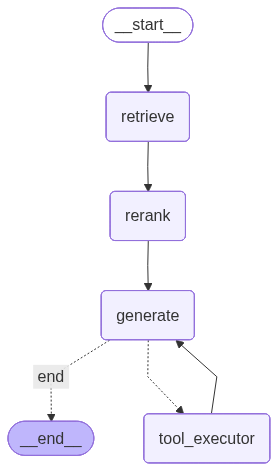

In [14]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(rag_chain.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_chain.get_graph().draw_mermaid())

## 4. 테스트

상호참조가 많은 쿼리로 tool 호출 루프를 검증

In [15]:
QUERIES = [
    "수익인식의 5단계에 대해서 상세히 설명해주세요.",
    "금융자산의 기대신용손실은 어떻게 측정하나요?",
    "수행의무를 식별하고 거래가격을 배분하는 기준은?",
    "연결재무제표 작성 시 지배력 판단 기준은?",
    "유형자산의 감가상각 방법에는 어떤 것들이 있나요?",
]

In [16]:
from IPython.display import Markdown

In [17]:
# Agentic RAG 테스트 (상호참조 자동 검색 포함)
result = rag_chain.invoke({
    "query": QUERIES[0],
    "messages": [],
    "iteration_count": 0,
    "fetched_chunk_ids": set(),
})

# 결과 요약
print(f"iteration_count: {result.get('iteration_count', 0)}")
print(f"context 문서 수: {len(result.get('context', []))}")
print(f"messages 수: {len(result.get('messages', []))}")
print(f"fetched_chunk_ids: {result.get('fetched_chunk_ids', set())}")
print()

# tool로 추가된 문서 표시
tool_fetched = [d for d in result.get("context", []) if d.metadata.get("fetched_by_tool")]
if tool_fetched:
    print(f"--- Tool로 추가 fetch된 문서 ({len(tool_fetched)}건) ---")
    for d in tool_fetched:
        m = d.metadata
        print(f"  {m.get('standard_id')} | {m.get('section_type')} | 문단 {m.get('para_number')}")
else:
    print("--- Tool 호출 없이 직접 답변 ---")

print()
display(Markdown(result["answer"]))

  [generate] iteration=0, context=5건, tool_calls=0
iteration_count: 0
context 문서 수: 5
messages 수: 3
fetched_chunk_ids: set()

--- Tool 호출 없이 직접 답변 ---



# K-IFRS 1115 수익인식의 5단계 상세 설명

제공된 기준서 내용을 바탕으로 수익인식의 5단계를 다음과 같이 설명드립니다.

## 5단계 체계

문단 IN7에 따르면, 핵심 원칙에 따라 수익을 인식하기 위해서는 다음의 5단계를 적용해야 합니다.

### **1단계: 고객과의 계약을 식별**
- 계약은 둘 이상의 당사자 사이에 집행 가능한 권리와 의무가 생기게 하는 합의입니다.
- K-IFRS 1115의 요구사항은 정해진 조건을 충족하는, 고객과 체결한 계약에만 적용됩니다.
- 여러 계약을 결합하여 하나의 계약으로 회계처리할 것을 요구하기도 합니다.
- 계약 변경의 회계처리에 관한 요구사항도 제공됩니다.

### **2단계: 수행의무를 식별**
- 하나의 계약은 고객에게 재화나 용역을 이전하는 여러 약속을 포함합니다.
- 재화나 용역이 **구별된다면** 약속은 수행의무이고 별도로 회계처리합니다.
- 구별되는 기준:
  - 고객이 재화나 용역 그 자체에서나 쉽게 구할 수 있는 다른 자원과 함께하여 효익을 얻을 수 있고
  - 그 약속을 계약 내의 다른 약속과 별도로 식별해 낼 수 있어야 합니다.

### **3단계: 거래가격을 산정**
- 거래가격은 고객에게 약속한 재화나 용역을 이전하고 그 대가로 기업이 **받을 권리를 갖게 될 것으로 예상하는 금액**입니다.
- 거래가격의 특징:
  - 고객이 지급하는 고정된 금액일 수도 있으나, 변동대가를 포함할 수 있습니다.
  - 현금 외의 형태로 지급될 수도 있습니다.
  - 계약에 유의적인 금융요소가 포함된다면 화폐의 시간가치 영향을 조정합니다.
  - 고객에게 지급하는 대가가 있는 경우에도 거래가격에서 조정합니다.
- 변동대가의 제약:
  - 변동대가는 변동대가와 관련된 불확실성이 나중에 해소될 때, **인식된 누적 수익 금액 중 유의적인 부분을 되돌리지 않을 가능성이 매우 높은 정도까지만** 거래가격에 포함합니다.

### **4단계: 거래가격을 계약 내 수행의무에 배분**
- 거래가격은 일반적으로 계약에서 약속한 각 **구별되는 재화나 용역의 상대적 개별 판매가격**을 기준으로 배분합니다.
- 개별 판매가격을 관측할 수 없다면 추정해야 합니다.
- 특수한 경우:
  - 거래가격에 계약의 일부분에만 관련되는 할인액이나 변동대가가 포함되는 경우가 있습니다.
  - 이 기준서에서는 할인액이나 변동대가를 일부 수행의무에만 배분하는 경우를 구체적으로 규정하고 있습니다.

### **5단계: 수행의무를 이행할 때 또는 기간에 걸쳐 이행하는 대로 수익을 인식**
- 기업이 약속한 재화나 용역을 고객에게 이전하여 수행의무를 이행할 때 **(이행하는 대로)** 수익을 인식합니다.
- 인식하는 수익 금액은 **이행한 수행의무에 배분된 금액**입니다.
- 수행의무의 이행 시점:
  - **한 시점에 이행**: 일반적으로 고객에게 재화를 이전하는 약속의 경우
  - **기간에 걸쳐 이행**: 일반적으로 고객에게 용역을 이전하는 약속의 경우 (문단 35 참조)
- 기간에 걸쳐 이행하는 수행의무의 수익은 그 수행의무의 **진행률을 적절하게 측정하는 방법**을 선택하여 기간에 걸쳐 인식합니다.

## 핵심 원칙

문단 IN7에 따르면, 이 기준서의 핵심 원칙은 **기업이 고객에게 약속한 재화나 용역의 이전을 나타내도록 해당 재화나 용역의 대가로 받을 권리를 갖게 될 것으로 예상하는 대가를 반영한 금액으로 수익을 인식**해야 한다는 것입니다.

In [18]:
result

{'query': '수익인식의 5단계에 대해서 상세히 설명해주세요.',
 'retrieved_docs': [Document(metadata={'chunk_id': 'KIFRS1115_bc_unk_51', 'parent_id': 'KIFRS1115_bc_h_이_기준서의_개요', 'standard_id': 'K-IFRS 1115', 'section_type': 'bc', 'para_number': None, 'cross_refs': [], 'has_table': False, 'has_example': False}, page_content='개관\n\nIN1 IFRS 15 ’ 고객과의 계약에서 생기는 수익 ‘ 에서는 고객과의 계약에\n\n서 생기는 수익 및 현금흐름의 특성, 금액, 시기, 불확실성에 대한\n\n유용한 정보를 재무제표이용자들에게 보고하기 위한 기준을 정한\n\n다 .\n\nIN2 IFRS 15 는 2018 년 1 월 1 일 이후 최초로 시작되는 회계연도부터\n\n적용하되 조기 적용할 수도 있다 .\n\nIN3 이 기준서는 다음의 기준서와 해석서를 대체한다 .\n\n(1) 기업회계기준서 제 1011 호 ‘ 건설계약 ’\n\n(2) 기업회계기준서 제 1018 호 ‘ 수익 ’\n\n(3) 기업회계기준해석서 제 2113 호 ‘ 고객충성제도 ’\n\n(4) 기업회계기준해석서 제 2115 호 ‘ 부동산건설약정 ’\n\n(5) 기업회계기준해석서 제 2118 호 ‘ 고객으로부터의 자산 이전 ’\n\n(6) 기업회계기준해석서 제 2031 호 ‘ 수익 : 광고용역의 교환거래 ’\n\n가 이 기준서를 공표한 이유\n\nIN4 수익은 재무제표이용자가 기업의 재무성과와 재무상태를 평가할\n\n때 중요한 수치이다 . 그러나 국제회계기준의 종전 수익인식 기준\n\n은 US GAAP 의 기준과 달랐고, 두 기준 모두 개선이 필요한 상\n\n황이었다 . IFRS 의 종전 수익인식 기준은 지침이 제한적이었고 그\n\n결과로 주요 기준서인 IAS 18 과 IAS 11 을 복잡한 거래에

In [19]:
client.close()
print("Qdrant 연결 종료")

Qdrant 연결 종료
